# 02a — Prompt Engineering Avanzado

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque2/02a-prompt-engineering.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> Este tema forma parte del **Bloque 2 — Orquestación**. Se recomienda
> haber completado el [Bloque 1](../bloque1/01-fundamentos.qmd) primero.

In [1]:
!pip install -q openai python-dotenv

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import json
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

In [3]:
from openai import OpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env en la raíz del proyecto con:\n    LLM_API_KEY=tu_api_key\n    Las celdas siguientes mostrarán este mensaje hasta que configures la clave.")
else:
    client = OpenAI(base_url=LLM_URL, api_key=LLM_KEY)

    # Utilidad para parsear JSON que puede venir envuelto en ```json ... ```
    def parse_json_response(content: str) -> dict:
        content = content.strip()
        if content.startswith("```"):
            content = content.split("```", 1)[1]
            if "```" in content:
                content = content.rsplit("```", 1)[0]
            content = content.strip()
            if content.startswith("json"):
                content = content[4:].strip()
        return json.loads(content)

    print("✅ Cliente OpenAI configurado. Las celdas de ejemplo funcionarán correctamente.")

✅ Cliente OpenAI configurado. Las celdas de ejemplo funcionarán correctamente.

## Prompt Engineering Avanzado

### ¿Qué es un prompt?

Un **prompt** es la instrucción textual que le damos a un LLM. Piensa en
ello como la pregunta o la orden que le das a un asistente muy capaz
pero muy literal: si la instrucción es ambigua, la respuesta será
imprecisa. Si es clara y con contexto, la respuesta será mucho mejor.

El Prompt Engineering consiste en diseñar estas instrucciones de forma
sistemática para obtener respuestas fiables, estructuradas y útiles, no
solo “texto bonito”.

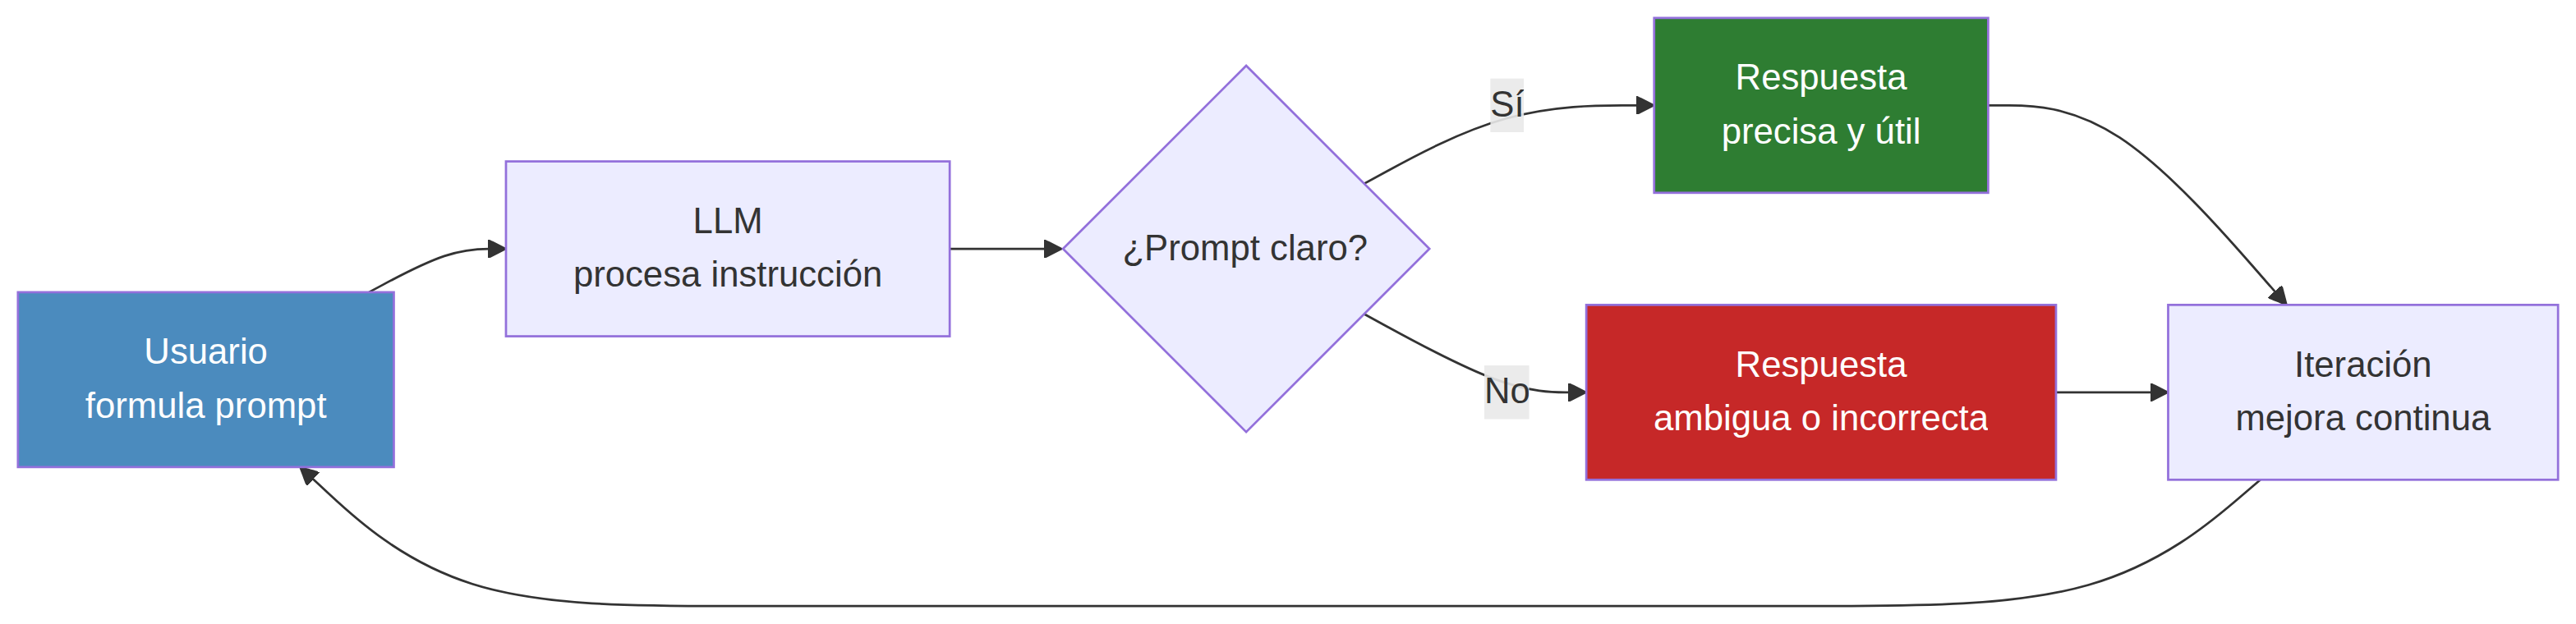

### Primer contacto: llamada a un LLM

Antes de profundizar, veamos cómo invocar un LLM desde Python con la API
de OpenAI (compatible con Llamus US, Ollama local, etc.):

In [4]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    respuesta = client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[{"role": "user", "content": "Explica qué es la desviación estándar en una frase."}]
    )
    print(respuesta.choices[0].message.content)

La desviación estándar es una medida que indica qué tan dispersos o variados están los datos con respecto a su promedio.

Este es el patrón base para todo lo que veremos: `model` + `messages` →
respuesta. Los `messages` pueden tener varios roles:

| Rol | Propósito | Ejemplo |
|------------------------|------------------------|------------------------|
| `system` | Instrucción global de comportamiento | “Eres un analista de datos experto” |
| `user` | Pregunta o instrucción del usuario | “Analiza este CSV…” |
| `assistant` | Respuestas previas del modelo (historial) | “La media es 42.3…” |

### Few-shot prompting

El **few-shot** consiste en incluir ejemplos dentro del prompt para que
el modelo entienda exactamente qué formato y estilo esperamos. Es como
enseñarle con el ejemplo.

In [5]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    prompt_few_shot = """
    Clasifica el sentimiento de cada frase como POSITIVO, NEGATIVO o NEUTRAL.

    Ejemplos:
    Frase: "El producto llegó roto y la atención fue pésima" → NEGATIVO
    Frase: "Todo perfecto, entrega rápida y bien embalado" → POSITIVO
    Frase: "El paquete llegó ayer por la tarde" → NEUTRAL

    Ahora clasifica:
    Frase: "El diseño es bonito pero la batería no dura nada"
    """

    respuesta = client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[{"role": "user", "content": prompt_few_shot}]
    )
    print(respuesta.choices[0].message.content)

NEGATIVO

**¿Por qué funciona?** Los LLMs son excelentes reconociendo patrones. Al
darles 2-3 ejemplos, el modelo “aprende” el patrón en contexto
(*in-context learning*) sin necesidad de fine-tuning.

> **Regla de oro del few-shot**
>
> - 2-3 ejemplos suelen bastar
> - Los ejemplos deben cubrir los casos extremos (edge cases)
> - Mantén consistencia exacta en el formato de los ejemplos

### Zero-shot vs Few-shot vs One-shot

| Estrategia | Ejemplos en el prompt | Cuándo usarlo |
|------------------------|------------------------|------------------------|
| **Zero-shot** | 0 — solo la instrucción | Tareas sencillas, modelos muy capaces |
| **One-shot** | 1 ejemplo | Cuando necesitas mostrar el formato exacto |
| **Few-shot** | 2-5 ejemplos | Tareas complejas, formatos muy específicos |

In [6]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    # ZERO-SHOT: sin ejemplos
    respuesta_zero = client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[{"role": "user", "content": "Traduce al inglés: 'El gato está en el tejado'"}]
    )

    # ONE-SHOT: un ejemplo
    respuesta_one = client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[{"role": "user", "content": """
    Traduce español → inglés.
    Ejemplo: "Hola mundo" → "Hello world"
    Ahora traduce: "El gato está en el tejado"
    """}]
    )

    print("Zero-shot:", respuesta_zero.choices[0].message.content)
    print("One-shot:", respuesta_one.choices[0].message.content)

Zero-shot: The most common translation is:

**The cat is on the roof.**
One-shot: The cat is on the roof.

### Chain-of-Thought (CoT)

El **Chain-of-Thought** consiste en pedir al modelo que razone paso a
paso antes de dar la respuesta final. La clave está en añadir algo como
*“pensemos paso a paso”* o incluir ejemplos donde se muestra el
razonamiento.

In [7]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    problema = """
    Un tren sale de Madrid a las 08:00 hacia Barcelona (620 km) a 120 km/h.
    Otro tren sale de Barcelona a las 09:00 hacia Madrid a 150 km/h.
    ¿A qué hora se cruzan?
    """

    prompt_cot = f"""
    {problema}

    Resuelve paso a paso:
    1. Calcula cuánto ha avanzado el primer tren cuando sale el segundo
    2. Calcula la distancia restante entre ambos en ese momento
    3. Calcula el tiempo hasta que se cruzan
    4. Suma el tiempo a la hora de salida
    """

    respuesta_cot = client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[{"role": "user", "content": prompt_cot}]
    )
    print(respuesta_cot.choices[0].message.content)

Este es un problema de movimiento relativo. Utilizaremos el método solicitado para resolverlo paso a paso.

**Datos iniciales:**
* Distancia total (D): 620 km
* Tren 1 (Madrid $\rightarrow$ Barcelona): Sale a las 08:00, Velocidad $V_1 = 120 \text{ km/h}$
* Tren 2 (Barcelona $\rightarrow$ Madrid): Sale a las 09:00, Velocidad $V_2 = 150 \text{ km/h}$

---

### 1. Calcula cuánto ha avanzado el primer tren cuando sale el segundo (a las 09:00)

El primer tren sale a las 08:00 y el segundo a las 09:00, por lo que el primer tren ha viajado durante 1 hora.

* Distancia recorrida por el Tren 1 = Velocidad $\times$ Tiempo
$$D_1 = 120 \text{ km/h} \times 1 \text{ h} = 120 \text{ km}$$

**Respuesta 1:** Cuando sale el segundo tren (a las 09:00), el primer tren ha avanzado **120 km**.

### 2. Calcula la distancia restante entre ambos en ese momento (a las 09:00)

Calculamos la distancia que queda por cubrir a partir de las 09:00.

* Distancia restante = Distancia total - Distancia recorrida
$$D_{re

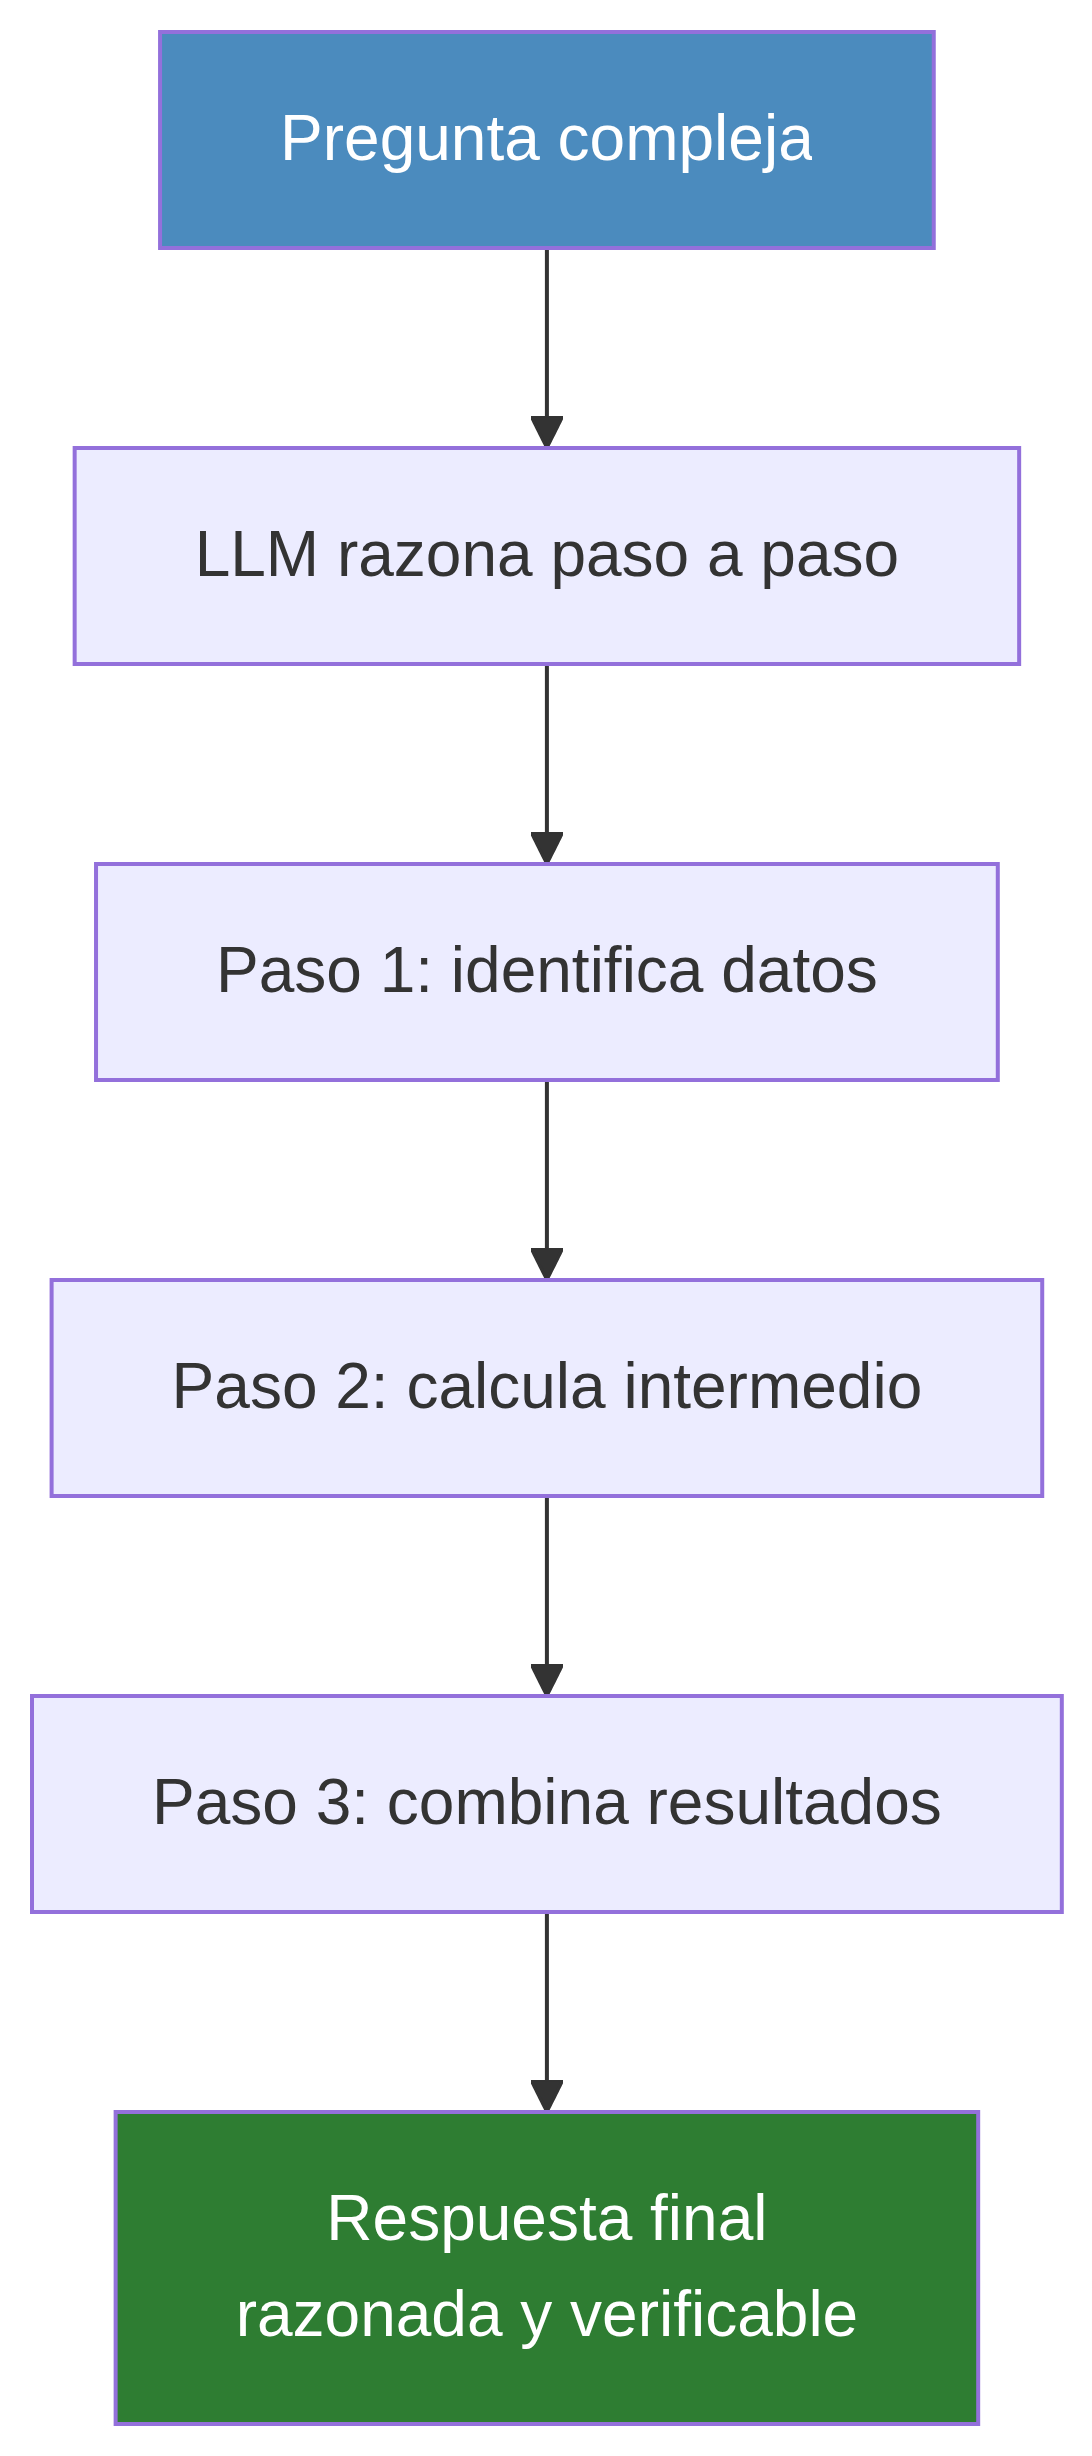

**¿Por qué funciona?** Al obligar al modelo a generar tokens intermedios
de razonamiento, cada paso condiciona el siguiente. Es como si el modelo
“pensara en voz alta”, reduciendo drásticamente los errores en tareas
matemáticas y lógicas.

### Tree-of-Thought (ToT)

El **Tree-of-Thought** extiende CoT: en lugar de un único camino de
razonamiento, el modelo explora múltiples ramas y elige la mejor. Es
útil para problemas con múltiples soluciones posibles (planificación,
puzzles, creatividad).

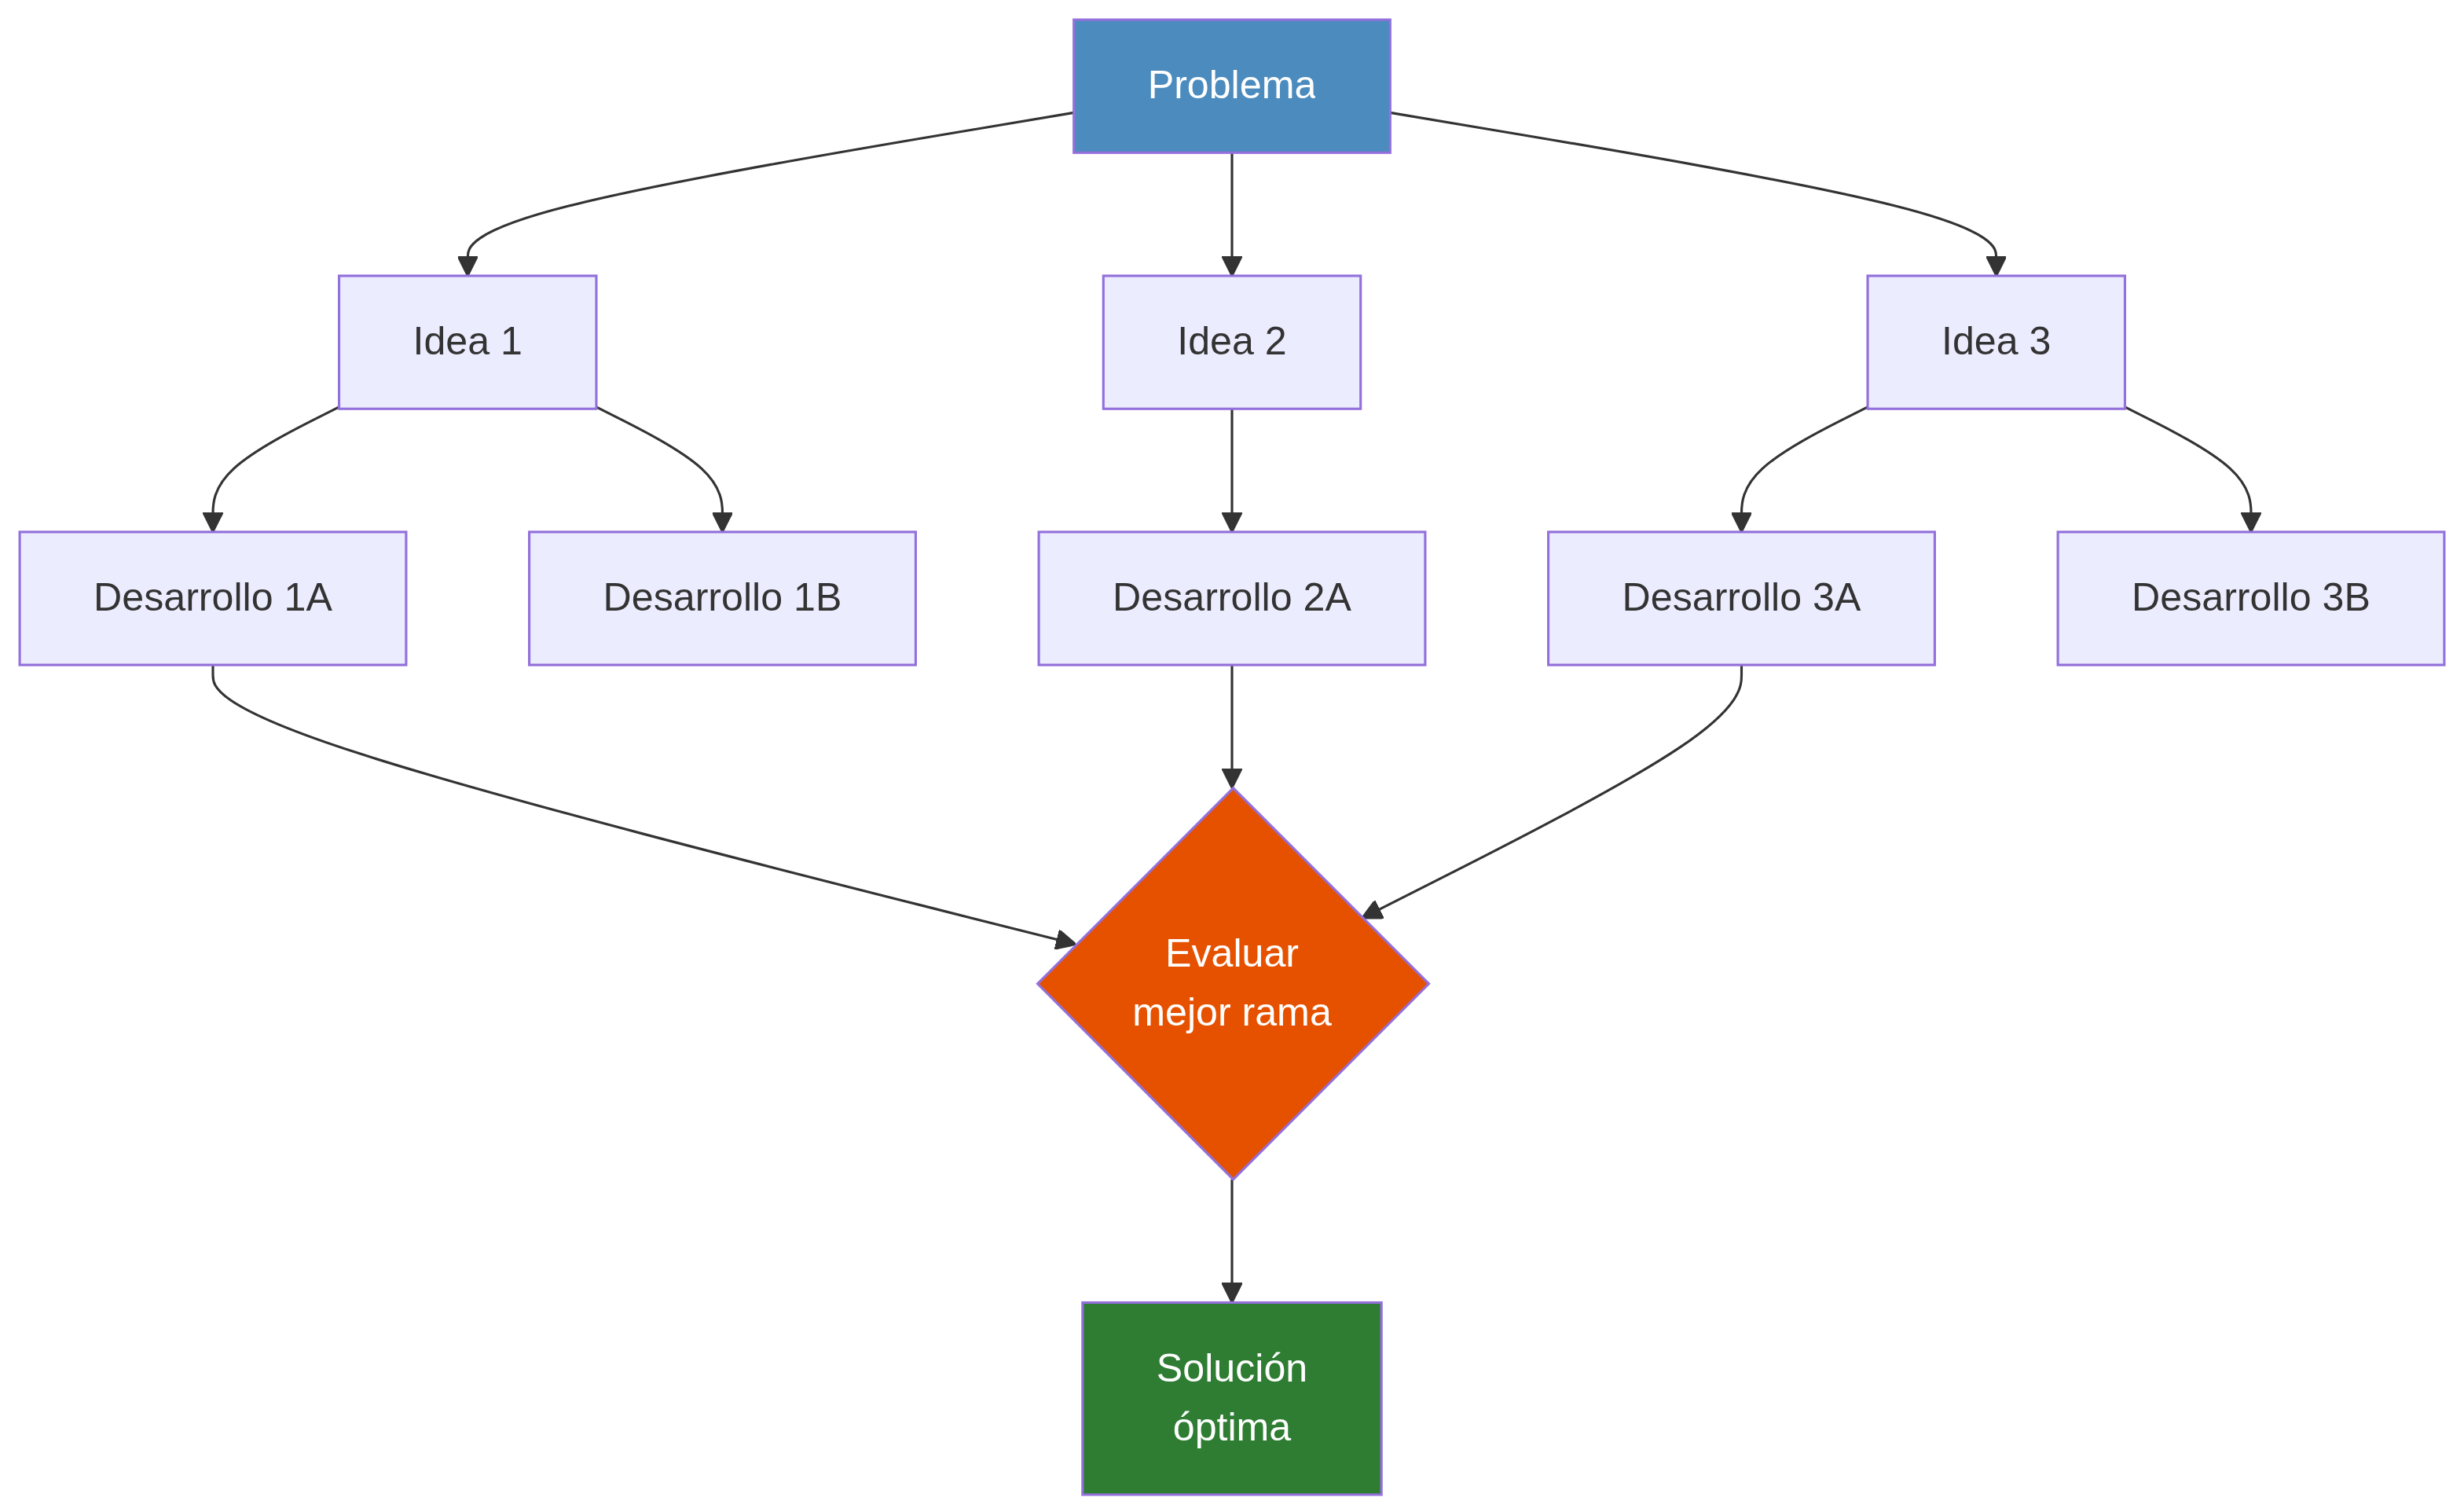

In [8]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    prompt_tot = """
    Quiero organizar una jornada de team building de 4 horas para 20 personas de un equipo de Data Science.

    Genera 3 enfoques distintos y para cada uno:
    - Describe brevemente la actividad principal
    - Evalúa pros y contras (coste, engagement, logística)
    - Elige el mejor y justifica por qué

    Al final, desarrolla en detalle solo la opción elegida.
    """

    respuesta = client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[{"role": "user", "content": prompt_tot}]
    )
    print(respuesta.choices[0].message.content)

¡Excelente iniciativa! Organizar un team building para un equipo de Data Science requiere actividades que fomenten el **pensamiento crítico**, la **colaboración estratégica** y la **comunicación efectiva**, más que solo juegos físicos.

A continuación, presento 3 enfoques distintos para su jornada de 4 horas, diseñados para potenciar las habilidades de su equipo.

---

## 📊 Enfoque 1: El Desafío Estratégico (Simulation Game)

Este enfoque se centra en la toma de decisiones bajo presión y la planificación estratégica. Ideal para un equipo que valora la lógica y los resultados.

| Descripción de la Actividad Principal | Evaluación (Pros y Contras) |
| :--- | :--- |
| **El Desafío del "MVP" (Minimum Viable Product):** Se divide al equipo en 4 o 5 subgrupos. Cada grupo recibe un escenario empresarial complejo (ej: Lanzar un producto en un mercado incierto, optimizar una cadena logística) con recursos limitados y datos ambiguos. Deben definir la estrategia, asignar roles (data scientist, PM

> **Note**
>
> ToT requiere más tokens (y por tanto más coste) que CoT simple, ya que
> se generan y evalúan múltiples ramas. En la práctica, se implementa
> con múltiples llamadas al LLM o agentes que evalúan cada rama.

### Output Structuring con JSON Schema

Forzar que el modelo devuelva JSON nos permite integrar el LLM en
pipelines automatizados. La API de OpenAI ofrece el parámetro
`response_format` para garantizar JSON válido:

In [9]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    texto_a_analizar = """
    Reunión del 15/03/2026. Asistentes: Ana (Data), Carlos (ML), Bea (Product).
    Se acordó migrar el pipeline ETL a Spark antes del Q2.
    Presupuesto estimado: 45.000€. Carlos se encarga de la POC.
    """

    system_prompt = f"""Eres un extractor de datos de actas de reunión.
Devuelve ÚNICAMENTE un JSON válido con esta estructura exacta, sin texto adicional:
{{
  "fecha": "string (formato YYYY-MM-DD)",
  "asistentes": ["lista de nombres"],
  "decisiones": ["lista de decisiones tomadas"],
  "presupuesto_euros": 0.0,
  "responsables": [{{"nombre": "string", "tarea": "string"}}]
}}"""

    respuesta = client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": texto_a_analizar}
        ],
    )

    try:
        resultado = parse_json_response(respuesta.choices[0].message.content)
        print(json.dumps(resultado, indent=2, ensure_ascii=False))
    except json.JSONDecodeError:
        print("⚠️ El modelo no devolvió JSON válido. Intenta de nuevo o usa un modelo con soporte nativo de structured output.")
        print(respuesta.choices[0].message.content[:200])

{
  "fecha": "2026-03-15",
  "asistentes": [
    "Ana",
    "Carlos",
    "Bea"
  ],
  "decisiones": [
    "Migrar el pipeline ETL a Spark antes del Q2"
  ],
  "presupuesto_euros": 45000.0,
  "responsables": [
    {
      "nombre": "Carlos",
      "tarea": "POC"
    }
  ]
}

> **JSON vía prompt vs. structured output nativo**
>
> Pedir JSON en el prompt funciona con **cualquier modelo**, pero **no
> garantiza** que el JSON sea válido (por eso añadimos `try/except`).
> Algunos modelos como Qwen 3 ofrecen `response_format` nativo que
> fuerza la estructura desde el API. La ventaja del prompting es que es
> **model-agnostic**: funciona con Gemma, Llama, Mistral, etc.

### De JSON Schema a datos sintéticos: el enfoque intuitivo

Lo que acabas de hacer —extraer 1 registro JSON de un texto— es el mismo
mecanismo que permite **generar datasets sintéticos completos**. La
diferencia es de escala: en lugar de pedir 1 registro, pides N. En lugar
de extraer de un texto real, pides al modelo que *invente* datos
verosímiles.

La receta es simple:

1.  **Define el schema** de tus datos (igual que en la sección anterior)
2.  **Añade few-shot examples** para que el modelo entienda el dominio y
    los rangos esperados
3.  **Controla la diversidad** con temperatura: baja produce datos
    conservadores, alta inyecta variedad
4.  **Itera en batch** para generar cientos o miles de registros

In [10]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    import pandas as pd

    system_prompt = """Eres un generador de datos sintéticos de clientes españoles.
Devuelve ÚNICAMENTE un JSON válido con esta estructura exacta, sin texto adicional:
{
  "clientes": [
    {
      "id": 1,
      "edad": 34,
      "ingresos_anuales": 42000.0,
      "provincia": "Madrid",
      "segmento": "premium"
    }
  ]
}
Reglas:
- Edad entre 18 y 80 años
- Ingresos entre 12000 y 120000, correlacionados con la edad
- Provincias: Madrid, Barcelona, Valencia, Sevilla, Bilbao, Málaga, Zaragoza
- Segmentos: premium, estandar, basic
- Genera variedad realista"""

    respuesta = client.chat.completions.create(
        model="gemma4:e2b-mlx",
        temperature=0.8,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": "Genera 10 clientes sintéticos. Usa variedad realista en edades, ingresos y provincias."}
        ],
    )

    try:
        datos = parse_json_response(respuesta.choices[0].message.content)
        df = pd.DataFrame(datos["clientes"])
        print(df.to_string(index=False))
        print(f"\n{len(df)} registros generados")
        print(f"   Edad: {df['edad'].min()}-{df['edad'].max()} (media {df['edad'].mean():.0f})")
        print(f"   Ingresos: {df['ingresos_anuales'].min():.0f}-{df['ingresos_anuales'].max():.0f} (media {df['ingresos_anuales'].mean():.0f})")
    except (json.JSONDecodeError, KeyError) as e:
        print(f"⚠️ Error al parsear respuesta: {e}")
        print(respuesta.choices[0].message.content[:200])

 id  edad  ingresos_anuales provincia segmento
  1    34           55000.0    Madrid  premium
  2    58           31000.0  Valencia estandar
  3    25           28500.0 Barcelona    basic
  4    41           62000.0   Sevilla  premium
  5    67           48000.0    Bilbao estandar
  6    31           15500.0  Zaragoza    basic
  7    52           75000.0    Madrid  premium
  8    29           39000.0    Málaga estandar
  9    45           81000.0  Valencia  premium
 10    78           22000.0   Sevilla    basic

10 registros generados
   Edad: 25-78 (media 46)
   Ingresos: 15500-81000 (media 45700)

> **¿Por qué funciona?**
>
> El LLM no “conoce” clientes reales, pero ha visto millones de patrones
> en sus datos de entrenamiento: distribuciones de edad, rangos de
> ingresos típicos, provincias españolas. El **prompt con el schema**,
> el **few-shot** y la **temperatura** controlan estructura, dominio y
> diversidad. Algunos modelos (Qwen, OpenAI) ofrecen además
> `response_format` nativo para forzar la estructura desde el API.
>
> **Este es el enfoque más intuitivo y accesible para datos
> sintéticos:** - Sin entrenar modelos adicionales - Sin GPU - En menos
> de 20 líneas de código - Funciona con cualquier modelo (Gemma, Qwen,
> Llama, etc.) - Ideal para prototipado, testing y aumento rápido de
> datasets pequeños

> **Limitaciones del enfoque intuitivo**
>
> - No garantiza **correlaciones realistas** entre columnas (ej.
>   ingresos vs. edad pueden no seguir la relación esperada)
> - Puede generar **valores atípicos** no representativos
> - Depende de la **calidad del prompt** y los ejemplos
> - **No hay garantía de privacidad** diferencial
>
> Para datasets de producción donde la fidelidad estadística es crítica,
> necesitarás modelos generativos especializados (CTGAN, TVAE, TabDDPM)
> que veremos en el **Bloque 3** con SDV.

### Role Prompting

Asignar un **rol** al modelo en el mensaje `system` cambia radicalmente
su comportamiento. No es magia: el modelo, entrenado con textos de
diversos perfiles, “activa” los patrones asociados a ese rol.

In [11]:
def consultar_como(rol, pregunta):
    return client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[
            {"role": "system", "content": rol},
            {"role": "user", "content": pregunta}
        ]
    ).choices[0].message.content

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    # Sin rol (genérico)
    print("=== SIN ROL ===")
    print(consultar_como("Eres un asistente útil.", "¿Qué opinas de usar la media en datos con outliers?"))

    # Con rol de analista senior
    print("\n=== ANALISTA SENIOR ===")
    print(consultar_como(
        "Eres un analista de datos senior con 15 años de experiencia en finanzas. "
        "Respondes con rigor estadístico, mencionas alternativas robustas y das ejemplos concretos.",
        "¿Qué opinas de usar la media en datos con outliers?"
    ))

    # Con rol de profesor divulgador
    print("\n=== PROFESOR DIVULGADOR ===")
    print(consultar_como(
        "Eres un profesor de estadística que explica conceptos a estudiantes de primero de carrera. "
        "Usas analogías cotidianas, evitas jerga innecesaria y pones ejemplos sencillos.",
        "¿Qué opinas de usar la media en datos con outliers?"
    ))

=== SIN ROL ===
Esta es una pregunta muy importante en el análisis de datos. La respuesta no es un simple "sí" o "no", sino **depende completamente del contexto y de la distribución de los datos**.

En resumen: **Usar la media (promedio) con outliers puede ser muy peligroso, ya que estos valores extremos sesgan significativamente el resultado.** Es necesario aplicar medidas estadísticas más robustas.

A continuación, te presento un análisis detallado sobre por qué ocurre esto y cuáles son las mejores alternativas.

---

## 1. ¿Por qué la Media es Problemática con Outliers?

La **media aritmética** se calcula sumando todos los valores y dividiéndolos por el número total de observaciones. Su principal debilidad es su **sensibilidad a valores extremos (outliers)**.

* **Sensibilidad Extrema:** Si tienes un conjunto de datos donde la mayoría son 10, pero hay un único valor de 10,000, la media se verá arrastrada y no reflejará el comportamiento central de los datos.
* **Sesgo (Skewness):** 

### Técnicas adicionales

| Técnica | Descripción | Cuándo usarla |
|------------------------|------------------------|------------------------|
| **Self-consistency** | Ejecutar CoT varias veces y votar la respuesta mayoritaria | Razonamiento matemático/lógico |
| **Generated knowledge** | Pedir al modelo que genere contexto antes de responder | Preguntas que requieren conocimiento factual |
| **Re-reading (RE2)** | Hacer que el modelo lea la pregunta dos veces | Mejora comprensión en tareas largas |
| **Emotion prompting** | Añadir estímulos emocionales al prompt | Tareas creativas o subjetivas |
| **Step-back prompting** | Preguntar primero por principios generales | Problemas muy específicos |

In [12]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    prompt_step_back = """
    Pregunta original: ¿Es 17 un número primo de Mersenne?

    Antes de responder, contesta:
    1. ¿Qué es un número primo de Mersenne? (definición general)
    2. ¿Cómo se comprueba si un número es primo de Mersenne? (método)
    3. Ahora aplica el método a 17 y concluye.
    """

    print(client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[{"role": "user", "content": prompt_step_back}]
    ).choices[0].message.content)

Esta es una excelente pregunta que requiere entender la definición específica de los números primos de Mersenne.

---

### 1. ¿Qué es un número primo de Mersenne? (Definición general)

Un **Número Primo de Mersenne** es un número primo $M_p$ que tiene la forma $2^p - 1$, donde $p$ es necesariamente un número primo.

*   $M_p = 2^p - 1$.
*   Para que $M_p$ sea un Número Primo de Mersenne, debe cumplir dos condiciones:
    1. El exponente $p$ debe ser primo. (Ejemplos: $3, 5, 7, 11, \dots$)
    2. El número resultante $M_p$ debe ser primo.

**Ejemplos:**
*   Si $p=2$: $M_2 = 2^2 - 1 = 3$. (3 es primo). $\rightarrow 3$ es un Número Primo de Mersenne.
*   Si $p=3$: $M_3 = 2^3 - 1 = 7$. (7 es primo). $\rightarrow 7$ es un Número Primo de Mersenne.
*Si $p=5$: $M_5 = 2^5 - 1 = 31$. (31 es primo). $\rightarrow 31$ es un Número Primo de Mersenne.

---

### 2. ¿Cómo se comprueba si un número es primo de Mersenne? (Método)

Para comprobar si un número $N$ es un Número Primo de Mersenne, se siguen

### Buenas prácticas resumen

1.  **Sé específico**: “analiza los datos” → malo. “calcula media,
    mediana y desviación típica de la columna ‘ventas’ agrupada por
    ‘región’” → bueno
2.  **Muestra, no solo digas**: incluye ejemplos del formato que esperas
    (few-shot)
3.  **Divide y vencerás**: tareas complejas → CoT, desglosa en pasos
4.  **Formato forzado**: usa `response_format` / JSON Schema cuando
    integres con código
5.  **Itera**: el primer prompt casi nunca es el óptimo. Prueba,
    compara, mejora
6.  **System prompt**: define el tono, rol y restricciones al inicio

> **Lectura recomendada:** [Prompt Engineering Guide
> (DAIR.AI)](https://www.promptingguide.ai/)